### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:
facturacion = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

print(facturacion)

{'Tienda 1': np.float64(1150880400.0), 'Tienda 2': np.float64(1116343500.0), 'Tienda 3': np.float64(1098019600.0), 'Tienda 4': np.float64(1038375700.0)}


# 2. Ventas por categoría

In [4]:
ventas_categoria_tienda1 = tienda.groupby("Categoría del Producto")["Precio"].sum()
ventas_categoria_tienda2 = tienda2.groupby("Categoría del Producto")["Precio"].sum()
ventas_categoria_tienda3 = tienda3.groupby("Categoría del Producto")["Precio"].sum()
ventas_categoria_tienda4 = tienda4.groupby("Categoría del Producto")["Precio"].sum()

print(ventas_categoria_tienda1)

Categoría del Producto
Artículos para el hogar     12698400.0
Deportes y diversión        39290000.0
Electrodomésticos          363685200.0
Electrónicos               429493500.0
Instrumentos musicales      91299000.0
Juguetes                    17995700.0
Libros                       8784900.0
Muebles                    187633700.0
Name: Precio, dtype: float64


# 3. Calificación promedio de la tienda


In [5]:
calificacion_tienda1 = tienda["Calificación"].mean()
calificacion_tienda2 = tienda2["Calificación"].mean()
calificacion_tienda3 = tienda3["Calificación"].mean()
calificacion_tienda4 = tienda4["Calificación"].mean()

print("Calificación Tienda 1:", calificacion_tienda1)
print("Calificación Tienda 2:", calificacion_tienda2)
print("Calificación Tienda 3:", calificacion_tienda3)
print("Calificación Tienda 4:", calificacion_tienda4)

Calificación Tienda 1: 3.976685036032217
Calificación Tienda 2: 4.037303942348453
Calificación Tienda 3: 4.048325561678677
Calificación Tienda 4: 3.9957591178965224


# 4. Productos más y menos vendidos

In [8]:
tiendas = [tienda, tienda2, tienda3, tienda4]

In [9]:
for i, df in enumerate(tiendas, start=1):

    conteo_productos = df["Producto"].value_counts()

    mas_vendido = conteo_productos.idxmax()
    menos_vendido = conteo_productos.idxmin()

    print(f"Tienda {i}")
    print("Producto más vendido:", mas_vendido)
    print("Producto menos vendido:", menos_vendido)
    print()

Tienda 1
Producto más vendido: Microondas
Producto menos vendido: Auriculares con micrófono

Tienda 2
Producto más vendido: Iniciando en programación
Producto menos vendido: Juego de mesa

Tienda 3
Producto más vendido: Kit de bancas
Producto menos vendido: Bloques de construcción

Tienda 4
Producto más vendido: Cama box
Producto menos vendido: Guitarra eléctrica



# 5. Envío promedio por tienda

In [10]:
tiendas = [tienda, tienda2, tienda3, tienda4]

for i, df in enumerate(tiendas, start=1):

    envio_promedio = df["Costo de envío"].mean()

    print(f"Tienda {i} - Envío promedio: {envio_promedio}")

Tienda 1 - Envío promedio: 26018.60958033065
Tienda 2 - Envío promedio: 25216.235693090293
Tienda 3 - Envío promedio: 24805.680373039424
Tienda 4 - Envío promedio: 23459.457167090754


**GRAFICOS**

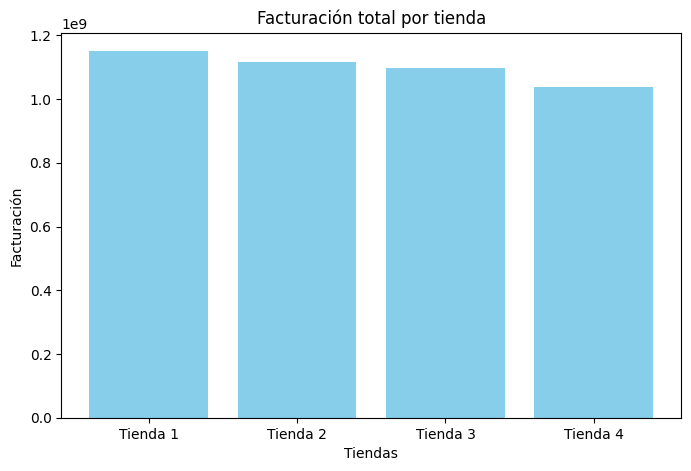

In [11]:
import matplotlib.pyplot as plt

facturacion = [
    tienda["Precio"].sum(),
    tienda2["Precio"].sum(),
    tienda3["Precio"].sum(),
    tienda4["Precio"].sum()
]

nombres_tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

plt.figure(figsize=(8,5))
plt.bar(nombres_tiendas, facturacion, color="skyblue")

plt.title("Facturación total por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Facturación")

plt.show()

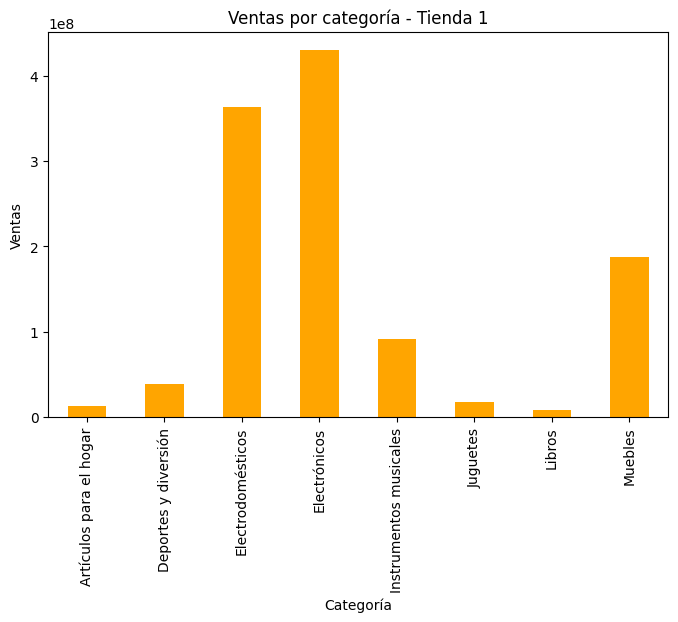

In [12]:
ventas_categoria = tienda.groupby("Categoría del Producto")["Precio"].sum()

plt.figure(figsize=(8,5))
ventas_categoria.plot(kind="bar", color="orange")

plt.title("Ventas por categoría - Tienda 1")
plt.xlabel("Categoría")
plt.ylabel("Ventas")

plt.show()

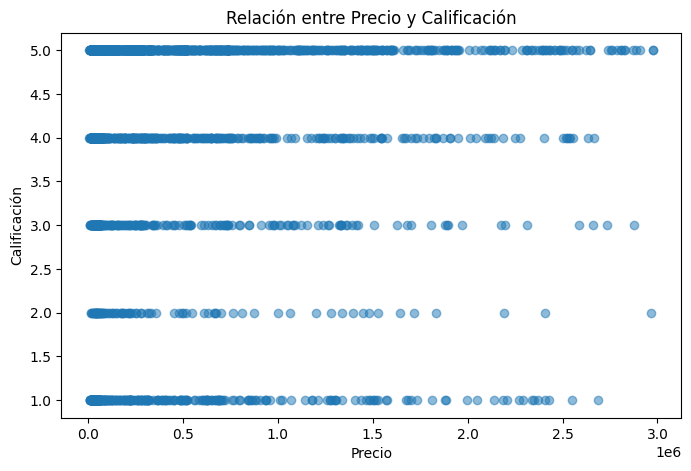

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(tienda["Precio"], tienda["Calificación"], alpha=0.5)

plt.title("Relación entre Precio y Calificación")
plt.xlabel("Precio")
plt.ylabel("Calificación")

plt.show()

**Informe Final del Análisis de Tiendas**

El presente análisis tiene como objetivo evaluar el desempeño de las cuatro tiendas del Sr. Juan con el fin de identificar cuál de ellas presenta el menor rendimiento y, por lo tanto, debería considerarse para la venta. Para ello, se analizaron diferentes indicadores clave como los ingresos totales, las categorías de productos más y menos vendidas, las calificaciones promedio de los clientes, los productos más y menos vendidos y el costo promedio de envío.

Además, se generaron visualizaciones utilizando Matplotlib para facilitar la interpretación de los datos y detectar patrones relevantes en el comportamiento de las ventas.

En primer lugar, se analizó la facturación total de cada tienda, lo cual permitió identificar cuál de ellas genera mayores ingresos. Este indicador es fundamental para comprender el rendimiento financiero de cada unidad de negocio.

Posteriormente, se evaluaron las categorías de productos más y menos vendidas, lo que permitió entender las preferencias de los clientes y detectar qué tipos de productos tienen mayor demanda en cada tienda.

También se analizaron las calificaciones promedio de los clientes, ya que estas reflejan el nivel de satisfacción del consumidor y la calidad del servicio ofrecido por cada tienda.

Otro aspecto importante fue el análisis de los productos más y menos vendidos, lo cual permitió identificar cuáles artículos generan mayor volumen de ventas y cuáles tienen menor rotación dentro del inventario.

Finalmente, se examinó el costo promedio de envío por tienda, ya que este factor puede influir tanto en la rentabilidad del negocio como en la experiencia del cliente.

Los gráficos generados permitieron visualizar claramente estas métricas, facilitando la comparación entre las distintas tiendas y resaltando los principales patrones en los datos.

CONCLUSIÓN:
Con base en el análisis realizado, se identificó lo siguiente: la Tienda 3 combina alta calificación promedio y facturación sólida, con un costo de envío moderado, lo que la hace más atractiva para retener clientes y mantener ventas.

La Tienda 1, aunque genera ingresos, presenta menor satisfacción del cliente y el envío más caro, lo que indica que es la que tiene mayor margen de mejora o la más adecuada para considerar vender.

Las Tiendas 2 y 4 tienen un desempeño intermedio, con buena calificación y envíos competitivos.

Por lo tanto, se recomienda que el Sr. Juan considere vender la Tienda 1, ya que es la que presenta menores indicadores de satisfacción y competitividad, mientras que conservar las demás tiendas permitirá mantener un buen rendimiento general y fidelidad de clientes.